In [1]:
import os, sys
import glob
import numpy as np
import pandas as pd
import xarray as xr
import subprocess

# ----------------------------
# set plotting styles
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.ioff()
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 18})
opj = os.path.join

In [2]:
idir = "/DATA/git/vrtc/mopsmap_tbx"
odir = opj(idir,'scatmat')
mopsmap_dir = '/data/vrtc/aerosol/mopsmap'
mopsmap_exe = opj(mopsmap_dir, 'mopsmap')
components = pd.read_csv(opj(idir,'data/opac_aerosol_components.csv'), skiprows=1, index_col=[1])
components['logS'] = np.log(components.sigma)
opac = pd.read_csv(opj(idir,'data/opac_aerosol_types.csv'), index_col=[0])

datapath = opj(mopsmap_dir, 'data')

input_file = './input.txt'

wl_min=0.35
wl_max=2.6


,Aerosol types,INSO,WASO,SOOT,SSAM,SSCM,MINM,MIAM,MICM,MITR,SUSO
name,,,,,,,,,,,
COCL,Continental clean,0.15,2600.0,0.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
COAV,Continental averaged,0.40,7000.0,8300.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
COPO,Continental polluted,0.60,15700.0,34300.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
URBA,Urban,1.50,28000.0,130000.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
DESE,Desert,0.00,2000.0,0.0,0.000,0.0000,269.5,30.5,0.142,0.0000,0.0
MACL,Maritime clean,0.00,1500.0,0.0,20.000,0.0032,0.0,0.0,0.000,0.0000,0.0
MAPO,Maritime polluted,0.00,3800.0,5180.0,20.000,0.0032,0.0,0.0,0.000,0.0000,0.0
MATR,Maritime tropical,0.00,590.0,0.0,10.000,0.0013,0.0,0.0,0.000,0.0000,0.0
ARCT,Arctic,0.01,1300.0,5300.0,1.900,0.0000,0.0,0.0,0.000,0.0000,0.0


In [3]:
components

,Component,sigma,rmed_N,rmed_V,rmin,rmax,density,Mstar,shape,kappa,refrac_index_file,logS
name,,,,,,,,,,,,
INSO,Insoluble,2.51,0.4710,6.00,0.005,20,2.0,23.70000,sphere,0.00,refr_insoluble,0.920283
WASO,Water-soluble,2.24,0.0212,0.15,0.005,20,1.8,0.00134,sphere,0.27,refr_water_soluble,0.806476
SOOT,Soot,2.00,0.0118,0.05,0.005,20,1.0,0.00006,sphere,0.00,refr_soot,0.693147
SSAM,Sea salt (acc.mode),2.03,0.2090,0.94,0.005,20,2.2,0.80200,spheroid,1.12,refr_seasalt,0.708036
SSCM,Sea salt (coa. mode),2.03,1.7500,7.90,0.005,60,2.2,224.00000,spheroid,1.12,refr_seasalt,0.708036
MINM,Mineral (nuc. mode),1.95,0.0700,0.27,0.005,20,2.6,0.02780,spheroid,0.10,refr_mineral,0.667829
MIAM,Mineral (acc. mode),2.00,0.3900,1.60,0.005,20,2.6,5.53000,spheroid,0.10,refr_mineral,0.693147
MICM,Mineral (coa. mode),2.15,1.9000,11.00,0.005,60,2.6,324.00000,spheroid,0.10,refr_mineral,0.765468
MITR,Mineral-transported,2.20,0.5000,3.00,0.020,5,2.5,15.90000,spheroid,0.05,refr_mineral,0.788457


In [4]:
opac

,Aerosol types,INSO,WASO,SOOT,SSAM,SSCM,MINM,MIAM,MICM,MITR,SUSO
name,,,,,,,,,,,
COCL,Continental clean,0.15,2600.0,0.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
COAV,Continental averaged,0.40,7000.0,8300.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
COPO,Continental polluted,0.60,15700.0,34300.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
URBA,Urban,1.50,28000.0,130000.0,0.000,0.0000,0.0,0.0,0.000,0.0000,0.0
DESE,Desert,0.00,2000.0,0.0,0.000,0.0000,269.5,30.5,0.142,0.0000,0.0
MACL,Maritime clean,0.00,1500.0,0.0,20.000,0.0032,0.0,0.0,0.000,0.0000,0.0
MAPO,Maritime polluted,0.00,3800.0,5180.0,20.000,0.0032,0.0,0.0,0.000,0.0000,0.0
MATR,Maritime tropical,0.00,590.0,0.0,10.000,0.0013,0.0,0.0,0.000,0.0000,0.0
ARCT,Arctic,0.01,1300.0,5300.0,1.900,0.0000,0.0,0.0,0.000,0.0000,0.0


In [40]:
# -- Write scattering angle file
# ang = np.concatenate([[0,0.001,0.005,0.01,0.05,0.1,0.2,0.3,0.4],np.arange(0.5,180.1,0.5)])
# pd.DataFrame(ang).to_csv(opj(datapath,'scat_angle_grid.txt'),index=False)

class input_info:
    def __init__(self,output_file='test.nc', dataroot=''):

        self.dataroot = dataroot
        self.output_file = output_file

    def write_mode(self, imode, rmed_N, sigma,
                   Nparticle=1, r_min=1e-3, r_max=60,
                   refra_file='refr_water_soluble',
                   shape='sphere',
                   kappa=0):
        mode = 'mode %d size log_normal %f %f %f %f %f\n' % (
            imode, rmed_N, sigma, Nparticle, r_min, r_max)
        mode += 'mode %d refrac file "%s"\n' % (imode, opj(self.dataroot, refra_file))
        mode += 'mode %d shape %s\n' % (imode, shape)
        mode += 'mode %d kappa %s\n' % (imode, kappa)
        return mode

    def write_info(self,
                   rel_humidity=0,
                   water_refrac_file="refr_water_segelstein",
                   wavelength='range 0.35 2.5 0.05',
                   theta_file='scat_angle_grid.txt',
                   scatlib='optical_dataset'):
        info = 'size_equ cs\n'
        info += 'rH %d\n' % rel_humidity
        info += 'water_refrac_file "%s"\n' % opj(self.dataroot, water_refrac_file)
        info += 'wavelength %s\n' % wavelength
        info += 'output theta_file "%s"\n' % opj(self.dataroot, theta_file)
        info += 'scatlib "%s"\n' % opj(self.dataroot, scatlib)
        info += 'output netcdf "%s" reff\n' % self.output_file
        return info

In [41]:

input_file = opj(idir,'input.txt')

xr_components = components.to_xarray()
rhs = [0, 50, 70]#, 80, 90, 95, 98, 99]
for rh in rhs:
    rh_num = rh / 100
    for name, opac_ in opac.iterrows():
        
        ofile = opj(odir, 'types', name + '_rh{:d}_scatmat.nc'.format(rh))

        if os.path.exists(ofile):
            continue
        print(name)
        print(ofile)
        imode = 0
        input = ""
        info = input_info(output_file=ofile, dataroot=datapath)
        # normalization of particle number
        norm = np.sum(opac_[1:])
        for component, Ni in opac_[1:].items():
            if Ni == 0:
                continue


            Ni_norm = Ni / norm
            imode += 1
            c = xr_components.sel(name=component)
            c = c.to_pandas()
            rmax = c['rmax']
            kappa = c['kappa']
            growth = (1 + kappa * rh_num / (1 - rh_num))**(1./3)
            xparam = 2 * np.pi * rmax / wl_min * growth
            # fix for the incomplete mopsmap x-parameter (upper value around 1010)
            if xparam > 1010:
                rmax = 1010 *wl_min / (2 * np.pi  * growth)
            print(component, Ni, kappa, xparam,rmax)



            if c['shape'] == 'sphere':
                input += info.write_mode(imode, c.rmed_N, c.sigma, shape='sphere', kappa=kappa, r_max=rmax,
                                         refra_file=c.refrac_index_file, Nparticle=Ni_norm)
            elif c['shape'] == 'spheroid':
                input += info.write_mode(imode, c.rmed_N, c.sigma,
                                         shape='spheroid distr_file "' + opj(datapath, 'ar_kandler') + '"', kappa=kappa,
                                         r_max=rmax, refra_file=c.refrac_index_file, Nparticle=Ni_norm)

        
        input += info.write_info(wavelength='range {:.3f} {:.3f} 0.05'.format(wl_min,wl_max), rel_humidity=rh)
        print(input)
        with open(input_file, 'w') as w:
            w.write(input)

        # call mopsmap
        
        p = subprocess.Popen(mopsmap_exe + ' ' + input_file, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             close_fds=True, shell=True)
        res = p.communicate()

SUSO
/DATA/git/vrtc/mopsmap_tbx/scatmat/types/SUSO_rh0_scatmat.nc
SUSO 1000.0 0.53 359.03916041026207 20
mode 1 size log_normal 0.069500 2.030000 1.000000 0.001000 20.000000
mode 1 refrac file "/data/vrtc/aerosol/mopsmap/data/refr_sulfate"
mode 1 shape sphere
mode 1 kappa 0.53
size_equ cs
rH 0
water_refrac_file "/data/vrtc/aerosol/mopsmap/data/refr_water_segelstein"
wavelength range 0.350 2.600 0.05
output theta_file "/data/vrtc/aerosol/mopsmap/data/scat_angle_grid.txt"
scatlib "/data/vrtc/aerosol/mopsmap/data/optical_dataset"
output netcdf "/DATA/git/vrtc/mopsmap_tbx/scatmat/types/SUSO_rh0_scatmat.nc" reff

SUSO
/DATA/git/vrtc/mopsmap_tbx/scatmat/types/SUSO_rh50_scatmat.nc
SUSO 1000.0 0.53 413.71915591022776 20
mode 1 size log_normal 0.069500 2.030000 1.000000 0.001000 20.000000
mode 1 refrac file "/data/vrtc/aerosol/mopsmap/data/refr_sulfate"
mode 1 shape sphere
mode 1 kappa 0.53
size_equ cs
rH 50
water_refrac_file "/data/vrtc/aerosol/mopsmap/data/refr_water_segelstein"
wavelength ra

In [20]:
res

(b'/data/vrtc/aerosol/mopsmap/mopsmap: error while loading shared libraries: libnetcdff.so.7: cannot open shared object file: No such file or directory\n',
 None)

In [25]:
name='WASO'
idir = "/DATA/git/vrtc/mopsmap_tbx"
files=opj(idir,'scatmat','types',name+'*.nc')

#------------------------------------
# load data
#------------------------------------
scatmat = []
for file in glob.glob(files):
    #print(file)
    name,rh = os.path.basename(file).replace('_scatmat.nc','').split('_')
    ds = xr.open_dataset(file)
    # reset dim and coords for practical use
    ds = ds.rename({'wavelen':'wl'}).rename({'nlam':'wl','nphamat':'scamat','nthetamax':'angle'}).set_coords('wl').set_index(wl='wl')
    scaang = ds.theta.isel(wl=0,scamat=0).squeeze().values
    ds = ds.assign_coords({'angle':scaang}).drop_vars('theta')
    ds['name']=name
    ds['rh']=rh
    scatmat.append(ds.set_coords(['name','wl','rh']))
scamat = xr.concat(scatmat,dim='name')
scamat

<xarray.Dataset> Size: 2MB
Dimensions:  (name: 3, nreff: 1, wl: 46, scamat: 6, angle: 376, nmommax: 129)
Coordinates:
  * wl       (wl) float64 368B 0.35 0.4 0.45 0.5 0.55 ... 2.4 2.45 2.5 2.55 2.6
  * angle    (angle) float32 2kB 180.0 179.5 179.0 178.5 ... 0.005 0.001 0.0
  * name     (name) <U4 48B 'WASO' 'WASO' 'WASO'
    rh       (name) <U4 48B 'rh0' 'rh70' 'rh50'
Dimensions without coordinates: nreff, scamat, nmommax
Data variables:
    reff     (name, nreff) float64 24B 0.1078 0.1268 0.1167
    phase    (name, wl, nreff, scamat, angle) float32 1MB 0.3535 ... 4.771
    pmom     (name, wl, nreff, scamat, nmommax) float32 427kB 1.0 ... -1.442e-20
    nmom     (name, wl, nreff, scamat) int32 3kB 129 129 129 129 ... 129 129 129
    ntheta   (name, wl, nreff, scamat) int32 3kB 376 376 376 376 ... 376 376 376
    ext      (name, wl, nreff) float64 1kB 0.007 0.006009 ... 0.0001382
    ssa      (name, wl, nreff) float64 1kB 0.9682 0.9686 ... 0.6758 0.6469
    rho      (name, nreff) float64 24B 2.6 1.982 2.26
    refre    (name, wl) float64 1kB 1.53 1.53 1.53 1.53 ... 1.385 1.383 1.38
    refim    (name, wl) float64 1kB 0.005 0.005 0.005 ... 0.01069 0.01156
Attributes:
    size_distr:        log-normal: r_mode   0.021; sigma   2.240; r_min   0.0...
    shape:             sphere
    file_info:         Netcdf file created using mopsmap
    version:           20090626
    parameterization:  Mie, T-matrix method, geometric optics

In [37]:
odir = opj(idir,'scatmat','ascii')

dir = "./"
file = "test.nc"
# ------------------------------------
# load data
# ------------------------------------
scatmat = []
for file in glob.glob(files):
    
    name, rh = os.path.basename(file).replace('_scatmat.nc', '').split('_')
    ds = xr.open_dataset(file)
    # reset dim and coords for practical use
    ds = ds.rename({'wavelen': 'wl'}).rename({'nlam': 'wl', 'nphamat': 'scamat', 'nthetamax': 'angle'}).set_coords('wl').set_index(wl='wl')
    scaang = ds.theta.isel(wl=0, scamat=0).squeeze().values
    ds = ds.assign_coords({'angle': scaang}).drop_vars('theta')
    ds = ds.squeeze()
    # put angle in increasing order
    ds = ds.isel(angle=slice(None, None, -1))
    ds['name'] = name
    ds['rh'] = rh
    theta_deg = ds.angle.round(4).values
    theta = np.radians(ds.angle)
    Nang = len(theta)
    for wl_, ds_ in ds.groupby('wl'):
        ofile = opj(odir, 'scat_mat_opac_' + name + '_' + rh + '_wl{:.1f}'.format(wl_ * 1000) + '.csv')
        if os.path.exists(ofile):
            continue
        print(wl_, ofile)
        
        S11 = ds_.phase.isel(scamat=0)
        np.trapz(S11 * np.sin(theta), theta) / 2
        minusS12 = -ds_.phase.isel(scamat=1) / S11
        S22 = ds_.phase.isel(scamat=4) / S11
        S33 = ds_.phase.isel(scamat=2) / S11
        mat = xr.Dataset({'s11': S11, 'minus_s12': minusS12, 's22': S22, 's33': S33})
        mat = mat.assign_coords(angle=theta_deg).squeeze()
        df_mat = mat.reset_coords(drop=True).to_pandas()
        Cext = ds_.ext
        ssa = ds_.ssa
        Csca = ssa * Cext
        Cext_ = "{:12.6e}".format(Cext.values[0])
        Csca_ = "{:12.6e}".format(Csca.values[0])
        header = 'Cext : ' + Cext_ + '\nCsca : ' + Csca_ + \
                 '\nNb angles : ' + str(Nang) + '\n'

        with open(ofile, 'w') as fp:
            fp.write(header)
        df_mat.to_csv(ofile, sep=' ', header=True, mode='a', float_format='%.8e')



0.35 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl350.0.csv
0.39999999999999997 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl400.0.csv
0.44999999999999996 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl450.0.csv
0.5 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl500.0.csv
0.55 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl550.0.csv
0.6 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl600.0.csv
0.65 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl650.0.csv
0.7 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl700.0.csv
0.75 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl750.0.csv
0.8 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl800.0.csv
0.85 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl850.0.csv
0.9 /DATA/git/vrtc/mopsmap_tbx/scatmat/ascii/scat_mat_opac_WASO_rh0_wl900.0.csv
0.9

In [36]:
df_mat

,s11,minus_s12,s22,s33
angle,,,,
0.000,13.349759,-0.000000e+00,1.0,1.000000
0.001,13.349759,-2.569509e-11,1.0,1.000000
0.005,13.349757,-6.423770e-10,1.0,1.000000
0.010,13.349752,-2.569504e-09,1.0,1.000000
0.050,13.349582,-6.423488e-08,1.0,1.000000
...,...,...,...,...
178.000,0.347334,-8.287903e-03,1.0,-0.999576
178.500,0.349973,-4.680000e-03,1.0,-0.999859
179.000,0.351909,-2.085915e-03,1.0,-0.999971


<Axes: xlabel='angle'>

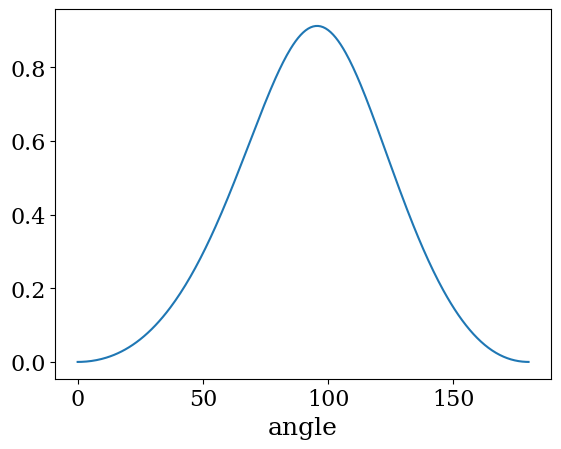

In [38]:
df_mat.minus_s12.plot()